# 新機能

- [whats news](https://aws.amazon.com/jp/about-aws/whats-new/2025/07/amazon-nova-canvas-virtual-try-on-style-options-image-generation/)
- [blog](https://aws.amazon.com/jp/blogs/aws/amazon-nova-canvas-update-virtual-try-on-and-style-options-now-available/)
- [blog (jp)](https://aws.amazon.com/jp/blogs/news/amazon-nova-canvas-update-virtual-try-on-and-style-options-now-available/)
- [doc-param](https://docs.aws.amazon.com/nova/latest/userguide/image-gen-req-resp-structure.html)
- [classmethod](https://dev.classmethod.jp/articles/amazon-nova-canvas-virtual-try-on-style-options-image-generation/)
- [aws-sample](https://github.com/aws-samples/sample-genai-design-studio/tree/main)


## helper


In [2]:
import base64
import io
import json

import boto3
from PIL import Image


def generate_image(
    payload: dict,
    num_image: int = 1,
    cfg_scale: float = 6.5,
    seed: int = 42,
    model_id: str = "amazon.nova-canvas-v1:0",
    save_image_name: str = "generated_image",
) -> None:
    client = boto3.client("bedrock-runtime", region_name="us-east-1")
    body = json.dumps(
        {
            **payload,
            "imageGenerationConfig": {
                "numberOfImages": num_image,  # Range: 1 to 5
                "quality": "premium",  # Options: standard/premium
                "height": 1024,  # Supported height list above
                "width": 1024,  # Supported width list above
                "cfgScale": cfg_scale,  # Range: 1.0 (exclusive) to 10.0
                "seed": seed,  # Range: 0 to 214783647
            },
        }
    )

    response = client.invoke_model(
        body=body,
        modelId=model_id,
        accept="application/json",
        contentType="application/json",
    )

    response_body = json.loads(response.get("body").read())
    base64_image = response_body.get("images")[0]
    base64_bytes = base64_image.encode("ascii")
    image_bytes = base64.b64decode(base64_bytes)

    image = Image.open(io.BytesIO(image_bytes))
    image.show()
    # save the image
    image.save(f"../images/virtual_try_on/results/{save_image_name}_seed={seed}.png")

    if "returnMask" in payload.get("virtualTryOnParams", {}):
        mask_base64 = response_body.get("maskImage")
        mask_bytes = base64.b64decode(mask_base64.encode("ascii"))
        mask_image = Image.open(io.BytesIO(mask_bytes))
        mask_image.show()
        # save the image
        mask_image.save(
            f"../images/virtual_try_on/results/{save_image_name}_mask_seed={seed}.png"
        )

In [3]:
def load_image_as_base64(image_path) -> str:
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [4]:
def resize_img(reference_img_path, resized_reference_img_path) -> None:
    img = Image.open(reference_img_path)
    img = img.resize((2048, 2048), Image.LANCZOS)
    img.save(resized_reference_img_path)

In [5]:
# ========== settings ==========
source_img_path = "../images/virtual_try_on/human.png"
reference_img_name = "swag_top_engineer"
# reference_img_name = "swag_aws_cb_cap"
# ========== settings ==========

reference_img_path = f"../images/virtual_try_on/{reference_img_name}.jpg"
resized_reference_img_path = (
    f"../images/virtual_try_on/{reference_img_name}_resized.jpg"
)
resize_img(reference_img_path, resized_reference_img_path)

## 衣服の置換パターン (Top Engineer Swag の試着)

他の Amazon Nova Canvas タスクタイプとは異なり，Virtual Try-On はテキストプロンプトやネガティブテキストプロンプトをサポートしていない．


In [159]:
# garmentClassをUPPER_BODY (上半身) に指定．この場合はうまくいく．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp1-1",
)

In [160]:
# garmentClassをLONG_SLEEVE_SHIRT (長袖シャツ) に指定．この場合もうまくいく．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "LONG_SLEEVE_SHIRT",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp1-2",
)

In [ ]:
# garmentClassをSHORT_SLEEVE_SHIRT (半袖シャツ) に指定．この場合はうまくいかない．
# 本パラメータでは，置換対象のマスクを指定する必要がある．指定したマスクの形状に厳密に従った生成を行う結果，このような結果となる．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "SHORT_SLEEVE_SHIRT",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp1-3",
)

## 上着の試着は可能


In [6]:
# ========== settings ==========
source_img_path = "../images/virtual_try_on/human.png"
reference_img_name = "swag_aws_hoodie"
# ========== settings ==========

reference_img_path = f"../images/virtual_try_on/{reference_img_name}.jpg"
resized_reference_img_path = (
    f"../images/virtual_try_on/{reference_img_name}_resized.jpg"
)
resize_img(reference_img_path, resized_reference_img_path)

In [163]:
# garmentClassをUPPER_BODY (上半身) に指定．この場合はうまくいく．
# 基本的には，厳密な体型に従ったマスクを生成し，そのマスク領域内で置換される．
# このため，パーカー特有のフードや全体の膨らみを表現できていない．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp2-1",
)

In [164]:
# garmentClassをUPPER_BODY (上半身) に指定．加えて，maskShapeをBOUNDING_BOX (バウンディングボックス) に指定．
# すると，置換対象のマスク領域がバウンディングボックスで指定され，置換領域をモデル側で広げてくれる．
# これにより，パーカーのフード部分を含めた置換（つまりはTシャツ領域に加え，背景部分を含めた置換）が可能になる．
# また，パーカー特有の膨らみも表現することができる．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp2-2",
)

In [165]:
# maskShapeをBOUNDING_BOXに指定する場合でかつ，画像の人物のポーズを固定化したい場合，maskExclusionsを指定する必要がある．これにより，置換対象のマスクから，手や顔，ポーズを除外することができる．（今回の例では分かりづらいですが，男性の左手は変更がなくなっていることがわかります．）

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp2-3",
)

# mergeStyle の検証


In [166]:
# maskShapeをBOUNDING_BOXに指定する場合でかつ，画像の人物のポーズを固定化したい場合，maskExclusionsを指定する必要がある．これにより，置換対象のマスクから，手や顔，ポーズを除外することができる．（今回の例では分かりづらいですが，男性の左手は変更がなくなっていることがわかります．）

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "mergeStyle": "DETAILED",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp3-1",
)

In [167]:
# mask領域と背景がシームレスになってる！！！

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "mergeStyle": "SEAMLESS",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp3-2",
)

In [168]:
# maskShapeをBOUNDING_BOXに指定する場合でかつ，画像の人物のポーズを固定化したい場合，maskExclusionsを指定する必要がある．これにより，置換対象のマスクから，手や顔，ポーズを除外することができる．（今回の例では分かりづらいですが，男性の左手は変更がなくなっていることがわかります．）

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "mergeStyle": "BALANCED",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp3-3",
)

## スタイリングの手がかり


In [169]:
# これはあまり意味ない．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    # "longSleeveStyle": "SLEEVE_UP",
                    "outerLayerStyle": "CLOSED",
                },
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "mergeStyle": "SEAMLESS",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp4-1",
)

In [ ]:
# インナーを保持できる設定

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    # "longSleeveStyle": "SLEEVE_UP",
                    "outerLayerStyle": "OPEN",
                },
            },
            "maskExclusions": {
                "preserveBodyPose": "ON",
                "preserveHands": "ON",
                "preserveFace": "ON",
            },
            "mergeStyle": "SEAMLESS",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp4-2-1",
)

In [13]:
# Qiita用

# インナーを保持できる設定

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    # "longSleeveStyle": "SLEEVE_UP",
                    "outerLayerStyle": "OPEN",
                },
            },
            # "maskExclusions": {
            #     "preserveBodyPose": "ON",
            #     "preserveHands": "ON",
            #     "preserveFace": "ON",
            # },
            # "mergeStyle": "SEAMLESS",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp4-2-2",
    seed=6,
)

In [14]:
# Qiita用

# インナーを保持できる設定

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    # "longSleeveStyle": "SLEEVE_UP",
                    "outerLayerStyle": "CLOSED",
                },
            },
            # "maskExclusions": {
            #     "preserveBodyPose": "ON",
            #     "preserveHands": "ON",
            #     "preserveFace": "ON",
            # },
            # "mergeStyle": "SEAMLESS",
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp4-2-3",
    # seed=,
)

In [16]:
# Qiita用

# インナーを保持できる設定

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    "outerLayerStyle": "OPEN",
                },
            },
            "mergeStyle": "SEAMLESS",
            "returnMask": True,
        },
    },
    save_image_name="exp3-2-1",
    # seed=,
)

In [17]:
# Qiita用

# インナーを保持できる設定

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
                "garmentStyling": {
                    "outerLayerStyle": "OPEN",
                },
            },
            "mergeStyle": "SEAMLESS",
            "returnMask": True,
        },
    },
    save_image_name="exp3-2-1",
    seed=1,
)

## mask 画像の試行


In [171]:
# maskShapeをBOUNDING_BOXに指定する場合でかつ，画像の人物のポーズを固定化したい場合，maskExclusionsを指定する必要がある．これにより，置換対象のマスクから，手や顔，ポーズを除外することができる．（今回の例では分かりづらいですが，男性の左手は変更がなくなっていることがわかります．）

import base64
import io
import json

import boto3
from PIL import Image


def generate_mask(
    payload: dict,
    num_image: int = 1,
    cfg_scale: float = 6.5,
    seed: int = 42,
    model_id: str = "amazon.nova-canvas-v1:0",
    save_image_name: str = "generated_mask",
) -> None:
    client = boto3.client("bedrock-runtime", region_name="us-east-1")
    body = json.dumps(
        {
            **payload,
            "imageGenerationConfig": {
                "numberOfImages": num_image,  # Range: 1 to 5
                "quality": "premium",  # Options: standard/premium
                "height": 1024,  # Supported height list above
                "width": 1024,  # Supported width list above
                "cfgScale": cfg_scale,  # Range: 1.0 (exclusive) to 10.0
                "seed": seed,  # Range: 0 to 214783647
            },
        }
    )

    response = client.invoke_model(
        body=body,
        modelId=model_id,
        accept="application/json",
        contentType="application/json",
    )

    response_body = json.loads(response.get("body").read())
    base64_image = response_body.get("maskImage")
    base64_bytes = base64_image.encode("ascii")
    image_bytes = base64.b64decode(base64_bytes)

    image = Image.open(io.BytesIO(image_bytes))
    image.show()

    # save the image
    image.save(f"../images/virtual_try_on/{save_image_name}_seed={seed}.png")

In [172]:
response = generate_mask(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp5-1",
)

In [173]:
response = generate_mask(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
            "returnMask": True,  # マスクを返す
        },
    },
    save_image_name="exp5-2",
)

In [174]:
response_body = json.loads(response.get("body").read())

AttributeError: 'NoneType' object has no attribute 'get'

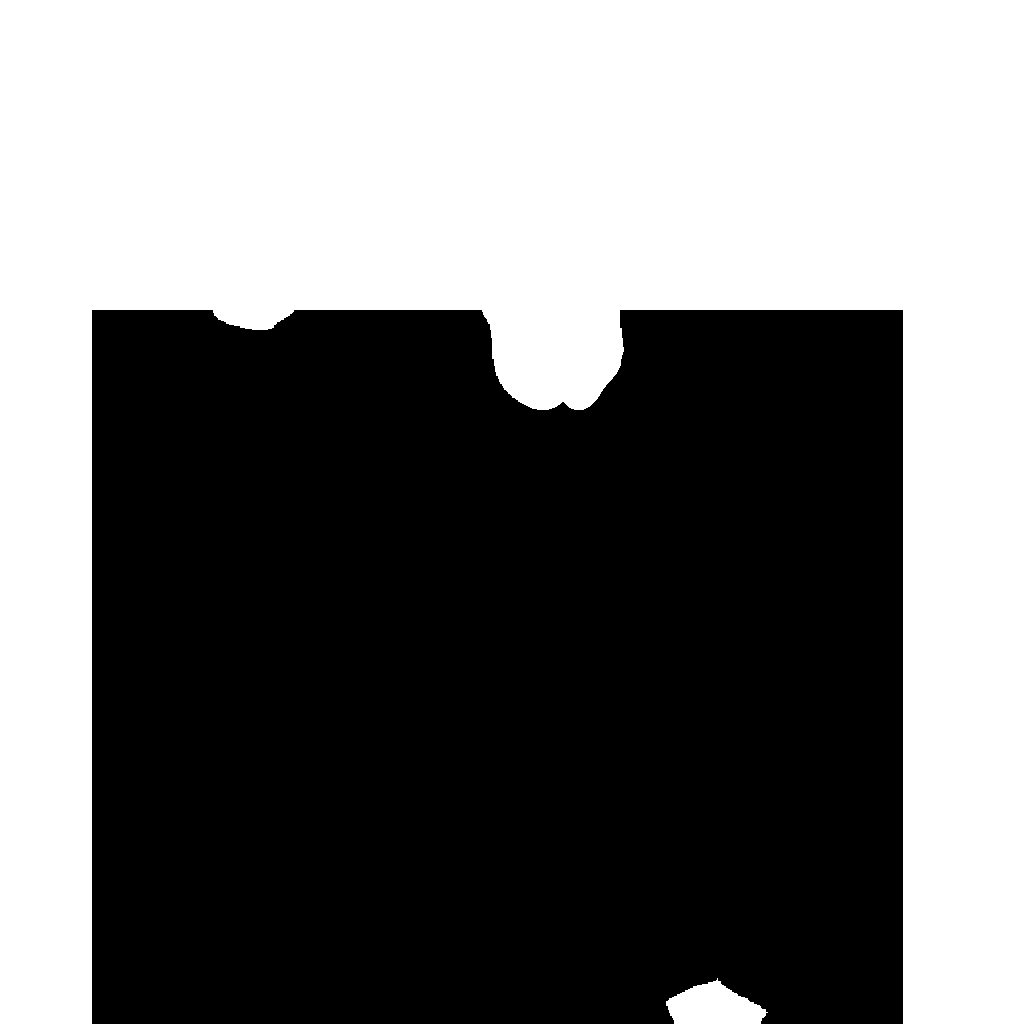

In [ ]:
# show key
# response_body.keys()

base64_image = response_body.get("maskImage")
base64_bytes = base64_image.encode("ascii")
image_bytes = base64.b64decode(base64_bytes)

image = Image.open(io.BytesIO(image_bytes))
image

In [ ]:
# garmentClassをUPPER_BODY (上半身) に指定．この場合はうまくいく．

# response = generate_mask(
#     {
#         "taskType": "VIRTUAL_TRY_ON",
#         "virtualTryOnParams": {
#             "sourceImage": load_image_as_base64(source_img_path),
#             "referenceImage": load_image_as_base64(resized_reference_img_path),
#             "maskType": "GARMENT",
#             "garmentBasedMask": {"garmentClass": "UPPER_BODY"},
#             "returnMask": True,  # マスクを返す
#         },
#     },
# )

In [ ]:
# response_body = json.loads(response.get("body").read())
# base64_image = response_body.get("maskImage")
# base64_bytes = base64_image.encode("ascii")
# image_bytes = base64.b64decode(base64_bytes)

# image = Image.open(io.BytesIO(image_bytes))
# image

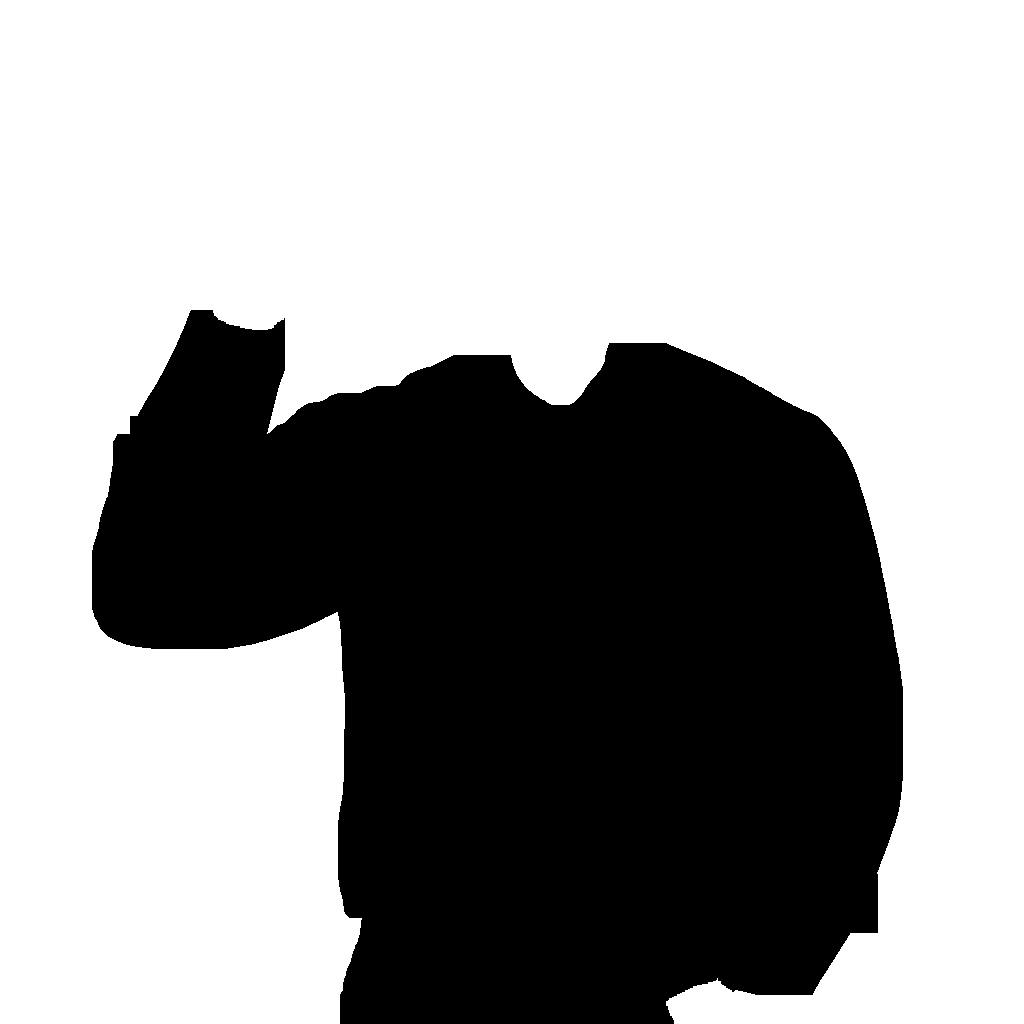

In [ ]:
# image

## 帽子は現時点ではサポートされていない


In [18]:
# ========== settings ==========
source_img_path = "../images/virtual_try_on/human.png"
# reference_img_name = "swag_top_engineer"
reference_img_name = "swag_aws_cb_cap"
# ========== settings ==========

reference_img_path = f"../images/virtual_try_on/{reference_img_name}.jpg"
resized_reference_img_path = (
    f"../images/virtual_try_on/{reference_img_name}_resized.jpg"
)
resize_img(reference_img_path, resized_reference_img_path)

In [19]:
# garmentClassをSHORT_SLEEVE_SHIRT (半袖シャツ) に指定．この場合はうまくいかない．
# 本パラメータでは，置換対象のマスクを指定する必要がある．指定したマスクの形状に厳密に従った生成を行う結果，このような結果となる．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {"garmentClass": "OTHER_UPPER_BODY"},
            "returnMask": True,
        },
    },
    save_image_name="expXXX",
)

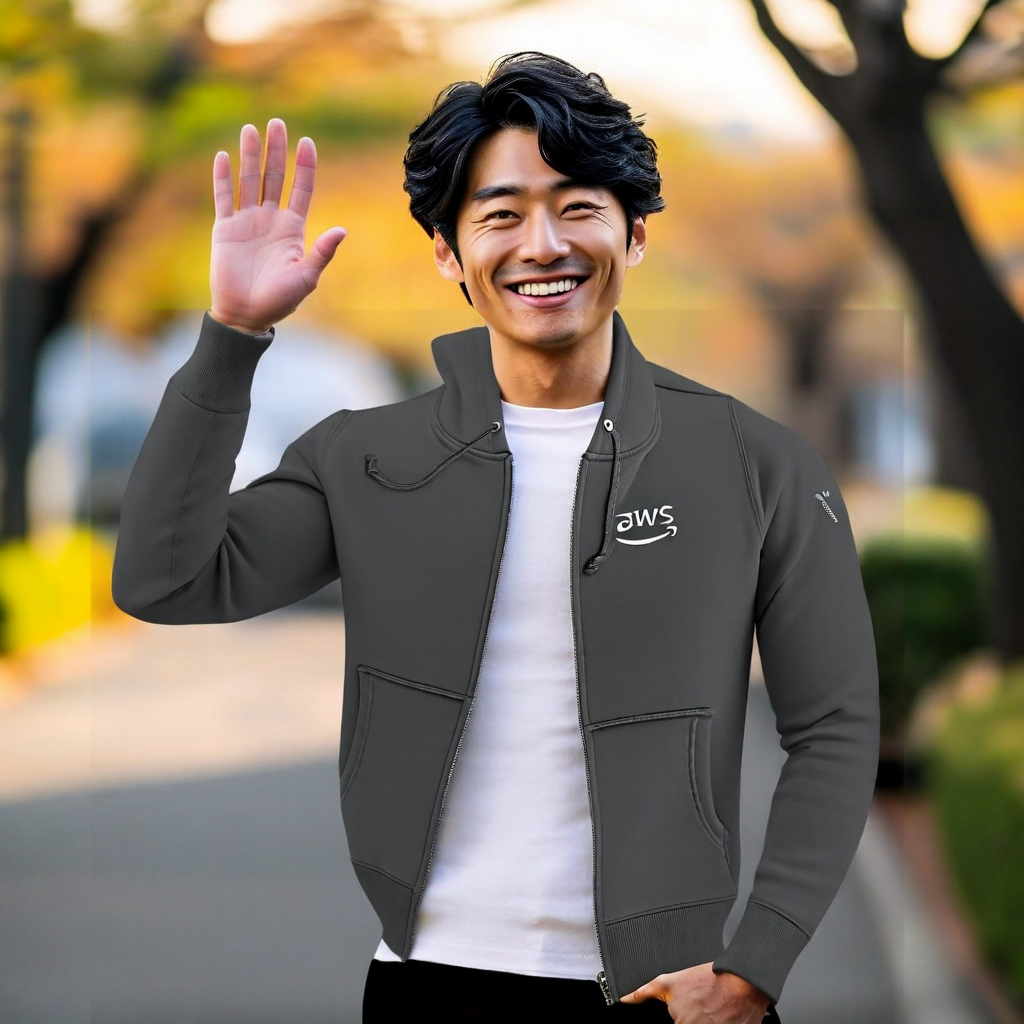

In [ ]:
# garmentClassをSHORT_SLEEVE_SHIRT (半袖シャツ) に指定．この場合はうまくいかない．
# 本パラメータでは，置換対象のマスクを指定する必要がある．指定したマスクの形状に厳密に従った生成を行う結果，このような結果となる．

generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "GARMENT",
            "garmentBasedMask": {
                "garmentClass": "OTHER_UPPER_BODY",
                "maskShape": "BOUNDING_BOX",
            },
        },
    },
)

## 家具（非衣服）の置換パターン


In [ ]:
# ========== settings ==========
source_img_path = "../images/virtual_try_on/human.png"
# reference_img_name = "swag_top_engineer"
reference_img_name = "swag_aws_cb_cap"
# ========== settings ==========

reference_img_path = f"../images/virtual_try_on/{reference_img_name}.jpg"
resized_reference_img_path = (
    f"../images/virtual_try_on/{reference_img_name}_resized.jpg"
)
resize_img(reference_img_path, resized_reference_img_path)

In [ ]:
generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "PROMPT",
            "promptBasedMask": {
                "maskShape": "BOUNDING_BOX",
                "maskPrompt": "head",
            },
        },
    },
)

In [ ]:
generate_image(
    {
        "taskType": "VIRTUAL_TRY_ON",
        "virtualTryOnParams": {
            "sourceImage": load_image_as_base64(source_img_path),
            "referenceImage": load_image_as_base64(resized_reference_img_path),
            "maskType": "PROMPT",
            "promptBasedMask": {
                "maskShape": "BOUNDING_BOX",
                "maskPrompt": "man",
            },
        },
    },
    seed=123,  # Change seed for different results
)